In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from ultralytics import YOLO

# Load pre-trained VisDrone YOLO model (yolov8s-visdrone offers a good balance of accuracy and speed)
model = YOLO('visdrone.pt')

# Filter for Pedestrian (0), People (1), and Car (3)
TARGET_CLASSES = [0, 1, 3]

In [2]:
def apply_edge_detection(frame: np.ndarray, low_thresh: int = 80, high_thresh: int = 180) -> np.ndarray:
    """Converts a BGR frame to grayscale and applies Canny edge detection."""
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    # Apply a gentle Gaussian blur to reduce high-frequency video noise
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, low_thresh, high_thresh)
    # Convert back to 3-channel BGR so it can be concatenated side-by-side with color frames
    return cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)

def run_visdrone_inference(frame: np.ndarray, model, classes: list, conf: float = 0.25) -> np.ndarray:
    """Runs YOLO VisDrone inference on a frame and returns the annotated bounding box image."""
    results = model.predict(frame, classes=classes, conf=conf, verbose=False)[0]
    return results.plot()

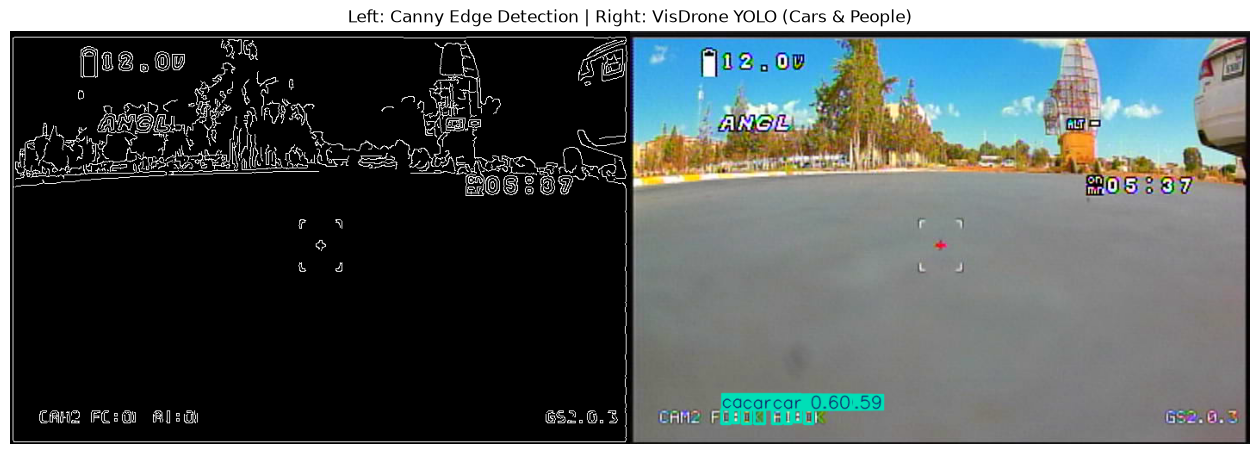

In [4]:
video_path = r"C:\Users\PC-LAB1\img_processing_lab\day11\fly_vedio\PICT0003.AVI"  # <-- Update with your .avi file path

cap = cv2.VideoCapture(video_path)
ret, test_frame = cap.read()
cap.release()

if ret:
    # Process single test frame
    edges_img = apply_edge_detection(test_frame)
    detection_img = run_visdrone_inference(test_frame, model, classes=TARGET_CLASSES)

    # Combine side-by-side for visual inspection
    side_by_side = np.hstack((edges_img, detection_img))

    # Display in notebook (OpenCV uses BGR, Matplotlib expects RGB)
    plt.figure(figsize=(16, 8))
    plt.imshow(cv2.cvtColor(side_by_side, cv2.COLOR_BGR2RGB))
    plt.title("Left: Canny Edge Detection | Right: VisDrone YOLO (Cars & People)")
    plt.axis("off")
    plt.show()
else:
    print(f"Error: Could not open video file at '{video_path}'. Check the file path.")

In [5]:
input_path = r"C:\Users\PC-LAB1\img_processing_lab\day11\fly_vedio\PICT0003.AVI"      # <-- Input file
output_path = "output_processed.avi" # <-- Output file

cap = cv2.VideoCapture(input_path)

# Extract video dimensions and properties
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Side-by-side frame width will be double the original width
combined_width = width * 2

# Initialize VideoWriter using the XVID codec for .avi format
fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter(output_path, fourcc, fps, (combined_width, height))

print(f"Processing '{input_path}' ({total_frames} total frames)...")

# Process frame-by-frame with a progress bar
pbar = tqdm(total=total_frames, desc="Rendering Video")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # 1. Edge Detection
    edge_frame = apply_edge_detection(frame, low_thresh=80, high_thresh=180)

    # 2. YOLO Object Detection
    detection_frame = run_visdrone_inference(frame, model, classes=TARGET_CLASSES, conf=0.25)

    # 3. Combine Edge view and YOLO view side-by-side
    combined_frame = np.hstack((edge_frame, detection_frame))

    # 4. Save to output video file
    out.write(combined_frame)
    pbar.update(1)

cap.release()
out.release()
pbar.close()

print(f"Processing complete! Output saved to: '{output_path}'")

Processing 'C:\Users\PC-LAB1\img_processing_lab\day11\fly_vedio\PICT0003.AVI' (18001 total frames)...


Rendering Video:   0%|          | 0/18001 [00:00<?, ?it/s]

KeyboardInterrupt: 